# brazilian e-comerce dataset

## Importar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.dates as mdates
import matplotlib.ticker as ticker

In [2]:
dataframe_orders = pd.read_csv('olist_orders_dataset.csv')
df_orders = dataframe_orders.copy()
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
dataframe_items = pd.read_csv('olist_order_items_dataset.csv')
df_items = dataframe_items.copy()
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
dataframe_products = pd.read_csv('olist_products_dataset.csv')
df_products = dataframe_products.copy()
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [5]:
dataframe_customers = pd.read_csv('olist_customers_dataset.csv')
df_customers = dataframe_customers.copy()
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Data from incomplete months at the beginning and end of the dataset were excluded to ensure consistency in trend analysis.

## Revenue por mes

In [6]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [7]:
df_orders_items = pd.merge(df_orders, df_items, on='order_id')
df_orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [8]:
df_orders_items.order_purchase_timestamp = pd.to_datetime(df_orders_items.order_purchase_timestamp)

In [9]:
df_orders_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   customer_id                    112650 non-null  str           
 2   order_status                   112650 non-null  str           
 3   order_purchase_timestamp       112650 non-null  datetime64[us]
 4   order_approved_at              112635 non-null  str           
 5   order_delivered_carrier_date   111456 non-null  str           
 6   order_delivered_customer_date  110196 non-null  str           
 7   order_estimated_delivery_date  112650 non-null  str           
 8   order_item_id                  112650 non-null  int64         
 9   product_id                     112650 non-null  str           
 10  seller_id                      112650 non-null  str           
 11  shipping_li

In [10]:
monthly_orders = df_orders_items.groupby(df_orders_items['order_purchase_timestamp'].dt.to_period('M'))['order_id'].nunique()
monthly_orders

order_purchase_timestamp
2016-09       3
2016-10     308
2016-12       1
2017-01     789
2017-02    1733
2017-03    2641
2017-04    2391
2017-05    3660
2017-06    3217
2017-07    3969
2017-08    4293
2017-09    4243
2017-10    4568
2017-11    7451
2017-12    5624
2018-01    7220
2018-02    6694
2018-03    7188
2018-04    6934
2018-05    6853
2018-06    6160
2018-07    6273
2018-08    6452
2018-09       1
Freq: M, Name: order_id, dtype: int64

In [11]:
valid_months = monthly_orders[monthly_orders > 500].index
df_orders_items = df_orders_items[df_orders_items['order_purchase_timestamp'].dt.to_period('M').isin(valid_months)]
df_orders_items

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


In [12]:
tabla1 = df_orders_items.groupby(df_orders_items['order_purchase_timestamp'].dt.to_period('M'))['price'].sum().reset_index()
tabla1.columns = ['purchase_date', 'revenue']
tabla1

,purchase_date,revenue
0,2017-01,120312.87
1,2017-02,247303.02
2,2017-03,374344.30
3,2017-04,359927.23
4,2017-05,506071.14
5,2017-06,433038.60
6,2017-07,498031.48
7,2017-08,573971.68
8,2017-09,624401.69
9,2017-10,664219.43


In [13]:
tabla1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   purchase_date  20 non-null     period[M]
 1   revenue        20 non-null     float64  
dtypes: float64(1), period[M](1)
memory usage: 452.0 bytes


In [14]:
tabla1["purchase_date"] = tabla1["purchase_date"].dt.to_timestamp()

In [15]:
tabla1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   purchase_date  20 non-null     datetime64[us]
 1   revenue        20 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 452.0 bytes


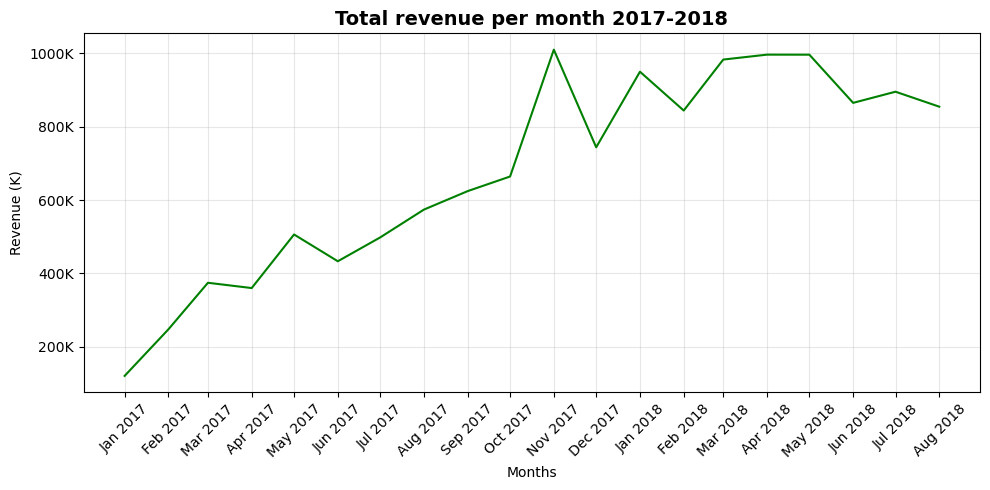

In [16]:
plt.figure(figsize=(10,5))
plt.style.use('default')

sns.lineplot(x="purchase_date", y="revenue", data=tabla1, color="green")

plt.grid(True, alpha=0.3)

plt.title("Total revenue per month 2017-2018", fontsize=14, weight="bold")
plt.xlabel("Months")
plt.ylabel("Revenue (K)")

# Formato de fechas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
# Formato en miles
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('images/revenue_per_month.png', bbox_inches='tight')
plt.show()

## Numero de ordenes por mes

In [17]:
df_orders.order_purchase_timestamp = pd.to_datetime(df_orders.order_purchase_timestamp)

In [18]:
df_orders = df_orders[df_orders['order_purchase_timestamp'].dt.to_period('M').isin(valid_months)]
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [19]:
tabla2 = df_orders.groupby(df_orders['order_purchase_timestamp'].dt.to_period('M'))['order_id'].count().reset_index()
tabla2.columns = ['purchase_date', 'orders']
tabla2

,purchase_date,orders
0,2017-01,800
1,2017-02,1780
2,2017-03,2682
3,2017-04,2404
4,2017-05,3700
5,2017-06,3245
6,2017-07,4026
7,2017-08,4331
8,2017-09,4285
9,2017-10,4631


In [20]:
tabla2["purchase_date"] = tabla2["purchase_date"].dt.to_timestamp()

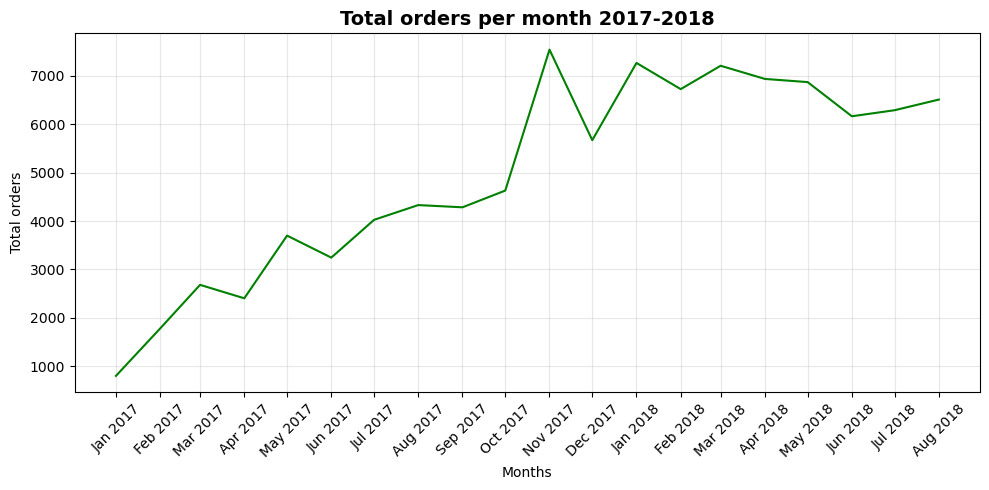

In [21]:
plt.figure(figsize=(10,5))
plt.style.use('default')

sns.lineplot(x="purchase_date", y="orders", data=tabla2, color="green")

plt.grid(True, alpha=0.3)

plt.title("Total orders per month 2017-2018", fontsize=14, weight="bold")
plt.xlabel("Months")
plt.ylabel("Total orders")

# Formato de fechas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())


plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('images/orders_per_monnth.png', bbox_inches='tight')
plt.show()

## Ticket promedio por mes

In [22]:
tabla3 = df_orders_items.groupby(
    df_orders_items['order_purchase_timestamp'].dt.to_period('M')
).agg(
    total_price=('price', 'sum'),
    total_orders=('order_id', 'nunique')
).assign(
    avg_price_per_order=lambda x: x['total_price'] / x['total_orders']
).reset_index()

tabla3

,order_purchase_timestamp,total_price,total_orders,avg_price_per_order
0,2017-01,120312.87,789,152.487795
1,2017-02,247303.02,1733,142.702262
2,2017-03,374344.30,2641,141.743393
3,2017-04,359927.23,2391,150.534182
4,2017-05,506071.14,3660,138.270803
5,2017-06,433038.60,3217,134.609450
6,2017-07,498031.48,3969,125.480343
7,2017-08,573971.68,4293,133.699436
8,2017-09,624401.69,4243,147.160427
9,2017-10,664219.43,4568,145.407056


In [23]:
tabla3["order_purchase_timestamp"] = tabla3["order_purchase_timestamp"].dt.to_timestamp()

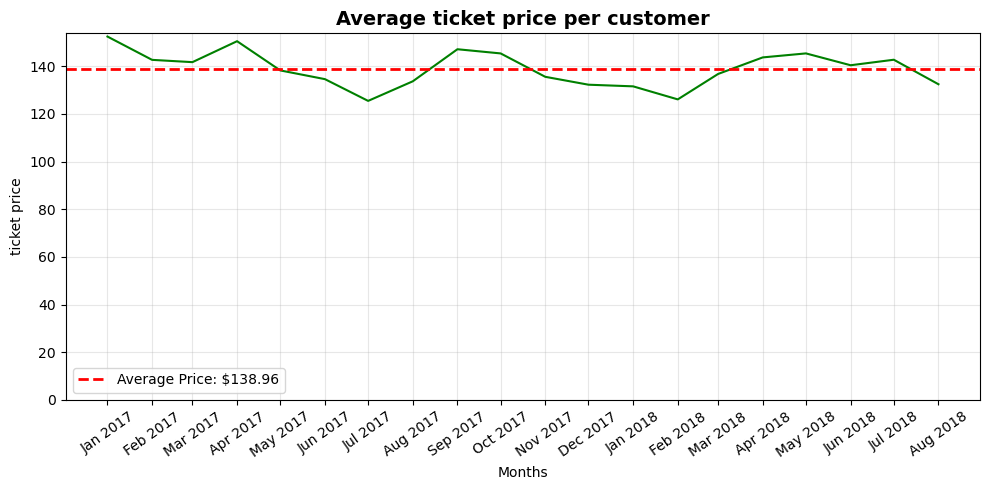

In [24]:
plt.figure(figsize=(10,5))
plt.style.use('default')
sns.lineplot(x="order_purchase_timestamp", y="avg_price_per_order", data=tabla3, color="green")

plt.grid(True, alpha=0.3)

plt.title("Average ticket price per customer", fontsize=14, weight="bold")
plt.xlabel("Months")
plt.ylabel("ticket price")

# Formato de fechas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

mean_price = tabla3['avg_price_per_order'].mean()
plt.axhline(y=mean_price, color="red", linewidth=2, linestyle="--", label=f"Average Price: ${mean_price:.2f}")
plt.legend()

plt.xticks(rotation=35)
plt.ylim(bottom=0)
plt.tight_layout()

plt.savefig('images/average_ticket.png', bbox_inches='tight')
plt.show()

## ¿Quién está generando ese crecimiento?

### 1️⃣ ¿Son nuevos clientes o clientes recurrentes?

In [25]:
df_orders_customers = pd.merge(df_orders, df_customers, on='customer_id')
df_orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [26]:
df_orders_customers['order_purchase_timestamp'] = pd.to_datetime(
    df_orders_customers['order_purchase_timestamp']
)

In [27]:
# Crear columna de mes del pedido
df_orders_customers['order_month'] = df_orders_customers['order_purchase_timestamp'].dt.to_period('M')
df_orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02


In [28]:
df_orders_customers = df_orders_customers[df_orders_customers['order_purchase_timestamp'].dt.to_period('M').isin(valid_months)]
df_orders_customers

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99087,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,2017-03
99088,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,2018-02
99089,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,2017-08
99090,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2018-01


In [29]:
# Obtener el primer mes de compra por cliente
first_purchase = df_orders_customers.groupby('customer_unique_id')['order_purchase_timestamp'].min().dt.to_period('M')
first_purchase

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    2018-05
0000b849f77a49e4a4ce2b2a4ca5be3f    2018-05
0000f46a3911fa3c0805444483337064    2017-03
0000f6ccb0745a6a4b88665a16c9f078    2017-10
0004aac84e0df4da2b147fca70cf8255    2017-11
                                     ...   
fffcf5a5ff07b0908bd4e2dbc735a684    2017-06
fffea47cd6d3cc0a88bd621562a9d061    2017-12
ffff371b4d645b6ecea244b27531430a    2017-02
ffff5962728ec6157033ef9805bacc48    2018-05
ffffd2657e2aad2907e67c3e9daecbeb    2017-05
Name: order_purchase_timestamp, Length: 95774, dtype: period[M]

In [30]:
# Mapear ese primer mes al dataframe
df_orders_customers['first_purchase_month'] = df_orders_customers['customer_unique_id'].map(first_purchase)
df_orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,first_purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10,2017-09
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02,2018-02


In [31]:
# Clasificar clientes (nuevo vs antiguo)
df_orders_customers['tipo_cliente'] = (
    df_orders_customers['order_month'] == df_orders_customers['first_purchase_month']
)

df_orders_customers['tipo_cliente'] = df_orders_customers['tipo_cliente'].map({
    True: 'cliente_nuevo',
    False: 'cliente_antiguo'
})
df_orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,first_purchase_month,tipo_cliente
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10,2017-09,cliente_antiguo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07,2018-07,cliente_nuevo
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08,2018-08,cliente_nuevo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11,2017-11,cliente_nuevo
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02,2018-02,cliente_nuevo


In [32]:
# Agrupar y contar clientes únicos por mes y tipo
tabla4 = (
    df_orders_customers
    .groupby(['order_month', 'tipo_cliente'])['customer_unique_id']
    .nunique()
    .unstack(fill_value=0)
    .rename(columns={
        'cliente_nuevo': 'clientes_nuevos',
        'cliente_antiguo': 'clientes_antiguos'
    }).reset_index()
)

In [33]:
tabla4

tipo_cliente,order_month,clientes_antiguos,clientes_nuevos
0,2017-01,0,765
1,2017-02,3,1752
2,2017-03,6,2636
3,2017-04,19,2353
4,2017-05,29,3596
5,2017-06,41,3139
6,2017-07,52,3895
7,2017-08,62,4184
8,2017-09,81,4131
9,2017-10,91,4470


In [34]:
tabla4["order_month"] = tabla4["order_month"].dt.to_timestamp()

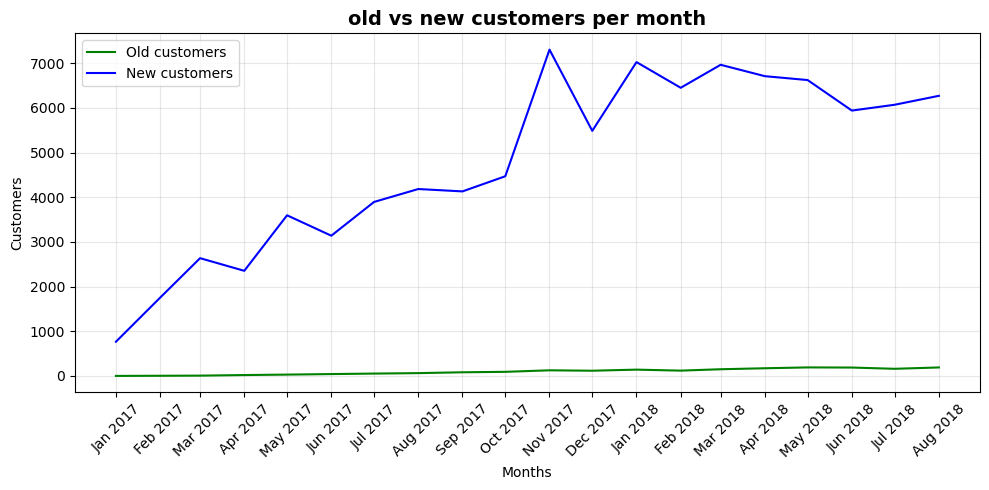

In [35]:
plt.figure(figsize=(10,5))
plt.style.use('default')

sns.lineplot(x="order_month", y="clientes_antiguos", data=tabla4, color="green", label="Old customers")
sns.lineplot(x="order_month", y="clientes_nuevos", data=tabla4, color="blue", label="New customers")

plt.grid(True, alpha=0.3)

plt.title("old vs new customers per month", fontsize=14, weight="bold")
plt.xlabel("Months")
plt.ylabel("Customers")

# Formato de fechas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())


plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('images/old_new_customers.png', bbox_inches='tight')
plt.show()

In [36]:
tabla5 = tabla4

In [37]:
tabla5['clientes_nuevosP'] = (tabla5.clientes_nuevos/(tabla5.clientes_nuevos + tabla5.clientes_antiguos))*100
tabla5['clientes_antiguosP'] = 100 - tabla5.clientes_nuevosP
tabla5

tipo_cliente,order_month,clientes_antiguos,clientes_nuevos,clientes_nuevosP,clientes_antiguosP
0,2017-01-01,0,765,100.000000,0.000000
1,2017-02-01,3,1752,99.829060,0.170940
2,2017-03-01,6,2636,99.772899,0.227101
3,2017-04-01,19,2353,99.198988,0.801012
4,2017-05-01,29,3596,99.200000,0.800000
5,2017-06-01,41,3139,98.710692,1.289308
6,2017-07-01,52,3895,98.682544,1.317456
7,2017-08-01,62,4184,98.539802,1.460198
8,2017-09-01,81,4131,98.076923,1.923077
9,2017-10-01,91,4470,98.004824,1.995176


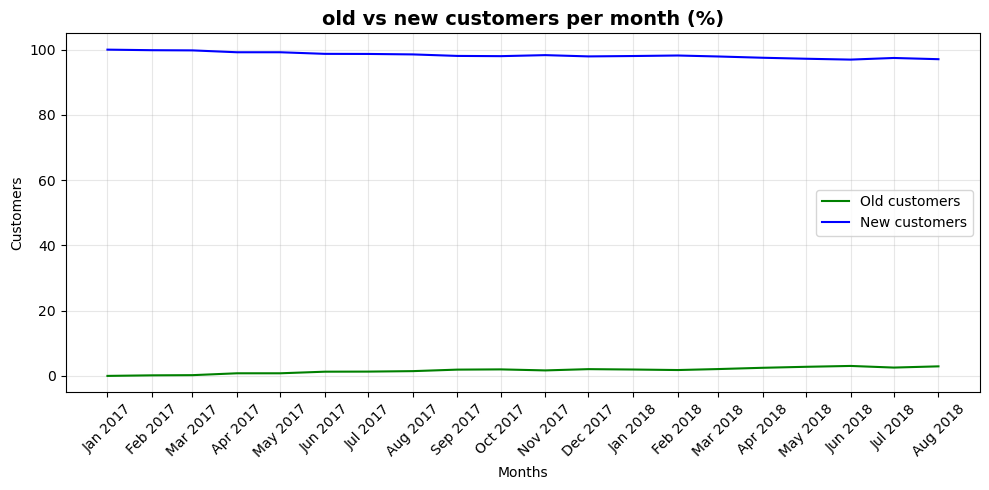

In [38]:
plt.figure(figsize=(10,5))
plt.style.use('default')

sns.lineplot(x="order_month", y="clientes_antiguosP", data=tabla5, color="green", label="Old customers")
sns.lineplot(x="order_month", y="clientes_nuevosP", data=tabla5, color="blue", label="New customers")

plt.grid(True, alpha=0.3)

plt.title("old vs new customers per month (%)", fontsize=14, weight="bold")
plt.xlabel("Months")
plt.ylabel("Customers")

# Formato de fechas
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())


plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('images/old_new_customers_percentage.png', bbox_inches='tight')
plt.show()

There are more new customers, accounting for more than 97% of customers in monthly sales, in 2017 alone

### 2️⃣ ¿Qué categorías de productos están impulsando el revenue?

In [39]:
df_orders_items = pd.merge(df_orders, df_items, on='order_id')
df_orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [40]:
df_orders_items_products = pd.merge(df_orders_items, df_products, on='product_id')
df_orders_items_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [41]:
df_orders_items_products = df_orders_items_products[df_orders_items_products['order_purchase_timestamp'].dt.to_period('M').isin(valid_months)]
df_orders_items_products

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112274,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,174.90,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0
112275,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,b80910977a37536adeddd63663f916ad,...,205.99,65.02,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0
112276,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,179.99,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
112277,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,179.99,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0


In [42]:
df_orders_items_products.groupby("product_category_name")["price"].sum().sort_values(ascending=False).reset_index()

,product_category_name,price
0,beleza_saude,1253993.86
1,relogios_presentes,1201645.44
2,cama_mesa_banho,1036509.69
3,esporte_lazer,984715.33
4,informatica_acessorios,910555.00
...,...,...
68,flores,1110.04
69,casa_conforto_2,760.27
70,cds_dvds_musicais,730.00
71,fashion_roupa_infanto_juvenil,569.85


In [43]:
df_cat = (
    df_orders_items_products
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Calcular porcentaje
df_cat["percentage"] = df_cat["price"] / df_cat["price"].sum() * 100

df_cat

,product_category_name,price,percentage
0,beleza_saude,1253993.86,9.384606
1,relogios_presentes,1201645.44,8.992842
2,cama_mesa_banho,1036509.69,7.757004
3,esporte_lazer,984715.33,7.369386
4,informatica_acessorios,910555.00,6.814387
...,...,...,...
68,flores,1110.04,0.008307
69,casa_conforto_2,760.27,0.005690
70,cds_dvds_musicais,730.00,0.005463
71,fashion_roupa_infanto_juvenil,569.85,0.004265


In [44]:
tabla6 = df_cat.head(10)
tabla6

,product_category_name,price,percentage
0,beleza_saude,1253993.86,9.384606
1,relogios_presentes,1201645.44,8.992842
2,cama_mesa_banho,1036509.69,7.757004
3,esporte_lazer,984715.33,7.369386
4,informatica_acessorios,910555.00,6.814387
5,moveis_decoracao,723881.71,5.417367
6,cool_stuff,634179.85,4.746058
7,utilidades_domesticas,630961.59,4.721973
8,automotivo,590886.86,4.422063
9,ferramentas_jardim,483896.58,3.621372


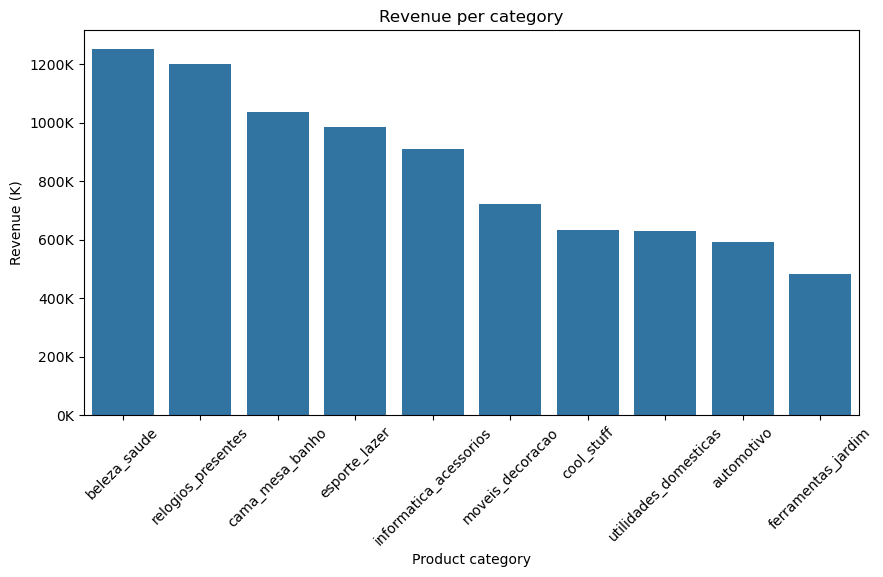

In [45]:
plt.figure(figsize=(10,5))
plt.style.use('default')

sns.barplot(
    data=tabla6,
    x="product_category_name",
    y="price"
)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
plt.xlabel("Product category")
plt.ylabel("Revenue (K)")
plt.xticks(rotation=45)
plt.title("Revenue per category")
plt.savefig('images/reveneue_per_category.png', bbox_inches='tight')
plt.show()

In [46]:
df_orders_items_products['order_purchase_timestamp'] = pd.to_datetime(
    df_orders_items_products['order_purchase_timestamp']
)

In [47]:
df_orders_items_products.groupby([df_orders_items_products['order_purchase_timestamp'].dt.to_period('M'), 'product_category_name'])['price'].sum().reset_index()

,order_purchase_timestamp,product_category_name,price
0,2017-01,agro_industria_e_comercio,65.97
1,2017-01,alimentos,42.82
2,2017-01,automotivo,5218.53
3,2017-01,bebes,6397.87
4,2017-01,beleza_saude,12561.32
...,...,...,...
1221,2018-08,relogios_presentes,72277.06
1222,2018-08,sinalizacao_e_seguranca,1825.59
1223,2018-08,telefonia,37541.89
1224,2018-08,telefonia_fixa,2724.17


In [48]:
result = (
    df_orders_items_products
    .groupby([
        df_orders_items_products['order_purchase_timestamp'].dt.to_period('M'),
        'product_category_name'
    ])['price']
    .sum()
    .reset_index()
    .loc[lambda df: df.groupby('order_purchase_timestamp')['price'].idxmax()]
).reset_index()
result

,index,order_purchase_timestamp,product_category_name,price
0,29,2017-01,moveis_decoracao,13521.31
1,48,2017-02,beleza_saude,22838.79
2,127,2017-03,informatica_acessorios,28624.60
3,172,2017-04,esporte_lazer,24864.33
4,214,2017-05,beleza_saude,46786.02
5,284,2017-06,cool_stuff,38244.50
6,337,2017-07,cama_mesa_banho,63888.75
7,396,2017-08,cama_mesa_banho,57137.23
8,502,2017-09,pcs,52878.88
9,570,2017-10,relogios_presentes,65959.53


In [49]:
result = pd.pivot_table(
    df_orders_items_products,
    values='price',
    index=df_orders_items_products['order_purchase_timestamp'].dt.to_period('M'),
    columns='product_category_name',
    aggfunc='sum',
    fill_value=0
)
result

product_category_name,agro_industria_e_comercio,alimentos,alimentos_bebidas,artes,artes_e_artesanato,artigos_de_festas,artigos_de_natal,audio,automotivo,bebes,...,pet_shop,portateis_casa_forno_e_cafe,portateis_cozinha_e_preparadores_de_alimentos,relogios_presentes,seguros_e_servicos,sinalizacao_e_seguranca,tablets_impressao_imagem,telefonia,telefonia_fixa,utilidades_domesticas
order_purchase_timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01,65.97,42.82,0.00,0.00,0.00,0.00,0.00,0.00,5218.53,6397.87,...,967.12,0.00,0.00,8086.52,183.29,0.00,0.00,2945.86,677.12,2827.58
2017-02,224.84,715.63,0.00,0.00,0.00,0.00,0.00,163.80,13162.40,3048.48,...,3729.07,0.00,0.00,11756.21,0.00,0.00,792.00,6899.09,759.23,12659.67
2017-03,81.99,2667.56,110.80,223.25,0.00,0.00,0.00,1134.77,14482.07,3724.08,...,8369.96,0.00,0.00,26770.38,0.00,75.00,495.00,8121.05,1592.35,13511.81
2017-04,0.00,491.30,47.90,119.90,0.00,0.00,69.00,942.20,15548.17,3980.45,...,6182.89,0.00,0.00,23487.78,0.00,128.06,1112.88,7245.87,2998.33,15028.84
2017-05,1579.94,387.90,416.29,6967.65,21.99,0.00,0.00,2081.18,18640.03,9849.51,...,8151.02,0.00,0.00,37973.90,0.00,508.85,1514.98,9264.10,462.33,21726.48
2017-06,1390.00,149.90,57.40,421.70,0.00,0.00,184.70,1671.00,31370.69,7864.74,...,5243.57,71.90,0.00,28948.63,0.00,273.90,594.00,6757.62,933.67,23623.71
2017-07,1180.00,584.16,168.20,386.75,129.90,69.90,65.09,771.69,14119.74,15941.11,...,6605.87,0.00,0.00,36804.56,0.00,530.19,198.00,9064.86,218.73,20874.30
2017-08,88.00,364.50,494.81,244.70,0.00,0.00,58.90,1050.70,20421.11,19982.13,...,10500.79,109.06,0.00,36419.20,0.00,377.80,450.89,10930.29,3343.54,23733.94
2017-09,1993.99,992.92,310.86,388.54,0.00,269.80,254.70,1042.59,14544.67,24366.30,...,8534.92,640.99,0.00,47135.60,100.00,438.40,233.90,18559.25,13692.91,20313.26


The three categories that generate the most revenue are:

1. beleza_saude2. relogios_presentes
3. cama_mesa_ban

With revenue between 2017 and 2018 of:
- 1258681.34
- 1205005.68
- 1036988.68

Percentage of total revenue between 2017 and 2018:

1. beleza_saude: 9.384664
2. relogios_presentees: 8.984461
3. cama_mesa_banho: 7.731735

## Por qué esas categorías son top?

### ¿venden mucho (volumen) o venden caro (precio)?

In [50]:
df_orders_items_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


#### Cantidad de ordenes por categoria 

In [51]:
tabla = df_orders_items_products.groupby('product_category_name')['order_id'].count().sort_values(ascending=False).reset_index()
tabla7 = tabla.head(10)
tabla7

,product_category_name,order_id
0,cama_mesa_banho,11107
1,beleza_saude,9619
2,esporte_lazer,8622
3,moveis_decoracao,8265
4,informatica_acessorios,7806
5,utilidades_domesticas,6952
6,relogios_presentes,5986
7,telefonia,4534
8,ferramentas_jardim,4342
9,automotivo,4223


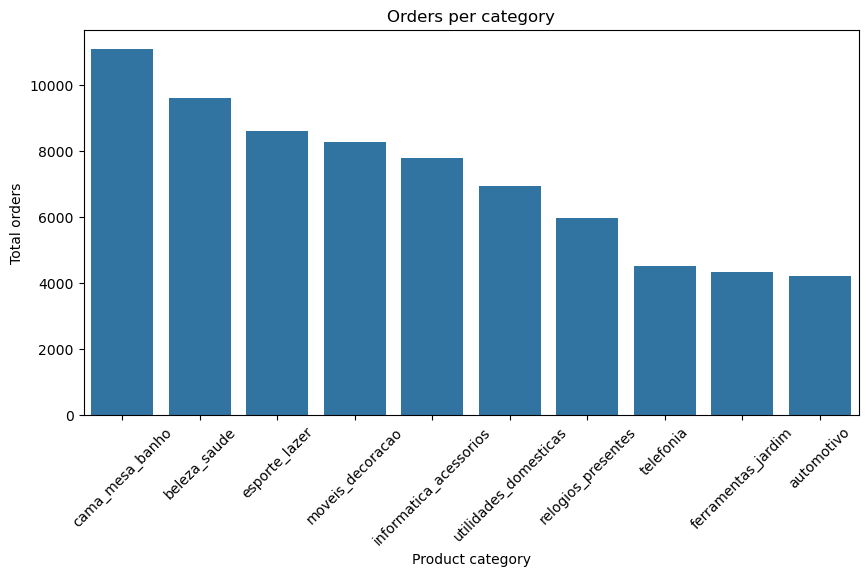

In [52]:
plt.figure(figsize=(10,5))
plt.style.use('default')

sns.barplot(
    data=tabla7,
    x="product_category_name",
    y="order_id"
)

plt.xlabel("Product category")
plt.ylabel("Total orders")
plt.xticks(rotation=45)
plt.title("Orders per category")
plt.show()

In [53]:
result_5 = df_orders_items_products[
    df_orders_items_products['product_category_name'].isin([
        'beleza_saude',
        'relogios_presentes',
        'cama_mesa_banho'
    ])
].groupby('product_category_name')['order_id'] \
 .count().sort_values(ascending=False).reset_index()

result_5.head(10)

,product_category_name,order_id
0,cama_mesa_banho,11107
1,beleza_saude,9619
2,relogios_presentes,5986


In [54]:
# Media de ordenes por categoria
tabla['order_id'].mean()

np.float64(1516.13698630137)

#### Precio promedio por orden por categoria

In [55]:
tabla_aux = df_orders_items_products.groupby('product_category_name')['price'].mean().sort_values(ascending=False).reset_index()
tabla8 = tabla_aux.head(10)
tabla8

,product_category_name,price
0,pcs,1098.340542
1,portateis_casa_forno_e_cafe,624.285658
2,eletrodomesticos_2,476.124958
3,agro_industria_e_comercio,342.124858
4,instrumentos_musicais,281.616000
5,eletroportateis,280.778468
6,portateis_cozinha_e_preparadores_de_alimentos,264.568667
7,telefonia_fixa,227.328649
8,construcao_ferramentas_seguranca,208.992371
9,relogios_presentes,200.742639


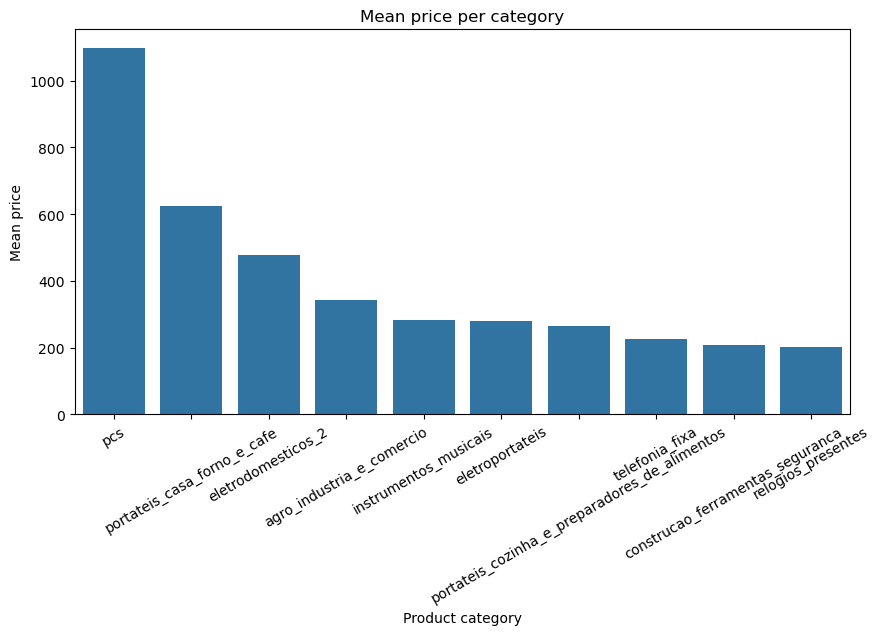

In [56]:
plt.figure(figsize=(10,5))
plt.style.use('default')

sns.barplot(
    data=tabla8,
    x="product_category_name",
    y="price"
)

plt.xlabel("Product category")
plt.ylabel("Mean price")
plt.xticks(rotation=30)
plt.title("Mean price per category")
plt.show()

In [57]:
result_6 = df_orders_items_products[
    df_orders_items_products['product_category_name'].isin([
        'beleza_saude',
        'relogios_presentes',
        'cama_mesa_banho'
    ])
].groupby('product_category_name')['price'] \
 .mean().sort_values(ascending=False).reset_index()


result_6.head(20)

,product_category_name,price
0,relogios_presentes,200.742639
1,beleza_saude,130.366344
2,cama_mesa_banho,93.320401


The three categories that generate the most revenue do so because of their high sales volume, with the average number of orders per category more than double the overall average. On the other hand, their average price per category is not too far off from the average product price.